In [1]:
# basic
import os
import pickle
import warnings
import numpy as np
import pandas as pd
from tqdm import tqdm
# pre processing
from sklearn import preprocessing as pre
# NN
import torch
import torch.nn as nn
from torch import Tensor
import torch.nn.functional as F
import torch.optim as optim
from torch.nn import MSELoss
from torch_geometric.nn import GCNConv
# val and plot
#from torchmetrics.regression import R2Score
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import mean_absolute_error
from loguru import logger as log
# plot
import matplotlib.pyplot as plt
# foundation model
from functools import reduce

/home/marcos/.pyenv/versions/3.10.13/envs/gnn-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
plt.style.use("seaborn-v0_8-whitegrid")
SEED = 1345
def seed_everything(seed):
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
seed_everything(SEED)
#plt.style.use('seaborn-whitegrid')
#pd.set_option('display.float_format', '{:.16f}'.format)
warnings.filterwarnings('ignore')

In [3]:
sb = pd.read_parquet("/home/marcos/loader_03-04_2024.parquet")
sb.head()

,125960550,230565994,258781031,43768720,44072192,44783654,44783914,44784438,45833547,47568123
2024-03-01 05:00:00,1.333333,0.000000,70.792221,41.188599,1.724359,14.955100,2.032506,3.571820,5.877792,7.546274
2024-03-01 05:30:00,3.595238,1.583333,229.051071,172.071198,8.282966,44.559937,11.048912,18.211931,18.912033,18.276293
2024-03-01 06:00:00,4.812975,3.268518,424.853729,433.062469,18.825665,97.263435,26.276600,41.471294,40.731876,37.141144
2024-03-01 06:30:00,9.215629,5.256614,630.444153,743.177368,25.593414,149.329544,49.763138,71.520836,57.200085,53.487366
2024-03-01 07:00:00,12.585028,6.152447,841.874512,1132.739502,44.350349,204.275940,78.721497,107.241295,77.808769,75.446609


In [4]:
serie = sb["125960550"]

In [5]:
total_points = sb.shape[0]
t = np.arange(total_points)

In [6]:
limite_marco = 31 * 40
limite_abril = limite_marco + (30 * 40)
limite_marco, limite_abril

(1240, 2440)

In [7]:
future_steps = sb.shape[0] - limite_abril
future_steps

1200

In [8]:
# --- 2. Parâmetros
input_size = 1       # entrada por passo de tempo
hidden_size = 32     # tamanho do hidden state da GRU
seq_len = 40         # número de passos anteriores usados para prever
train_points = limite_abril  # 1 mês
future_steps = future_steps  # prever 2 meses
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [9]:
# --- 3. Criar janelas deslizantes (X = janelas, y = próximo ponto)
def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(serie[:train_points], seq_len)

X_train = torch.tensor(X_train, dtype=torch.float32).unsqueeze(-1).to(device)  # (batch, seq_len, 1)
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1).to(device)   # (batch, 1)
X_train.shape, y_train.shape

(torch.Size([2400, 40, 1]), torch.Size([2400, 1]))

## Model

In [10]:
class GRUNet(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(GRUNet, self).__init__()
        self.gru = nn.GRU(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        _, h = self.gru(x)  # h: (1, batch, hidden)
        out = self.fc(h.squeeze(0))  # (batch, hidden) -> (batch, 1)
        return out

In [11]:
model = GRUNet(input_size=1, hidden_size=hidden_size).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [12]:
# --- 5. Treinamento
epochs = 500
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    output = model(X_train)
    loss = criterion(output, y_train)
    loss.backward()
    optimizer.step()
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")

Epoch 10/500, Loss: 167.6084
Epoch 20/500, Loss: 155.2643
Epoch 30/500, Loss: 142.8734
Epoch 40/500, Loss: 130.8588
Epoch 50/500, Loss: 119.5578
Epoch 60/500, Loss: 109.3990
Epoch 70/500, Loss: 100.8363
Epoch 80/500, Loss: 93.5643
Epoch 90/500, Loss: 87.1964
Epoch 100/500, Loss: 81.6554
Epoch 110/500, Loss: 76.7977
Epoch 120/500, Loss: 72.4377
Epoch 130/500, Loss: 68.4799
Epoch 140/500, Loss: 64.8721
Epoch 150/500, Loss: 61.5718
Epoch 160/500, Loss: 58.5479
Epoch 170/500, Loss: 55.7755
Epoch 180/500, Loss: 53.2334
Epoch 190/500, Loss: 50.9025
Epoch 200/500, Loss: 48.7652
Epoch 210/500, Loss: 46.8049
Epoch 220/500, Loss: 45.0062
Epoch 230/500, Loss: 43.3539
Epoch 240/500, Loss: 41.8291
Epoch 250/500, Loss: 40.4089
Epoch 260/500, Loss: 39.0766
Epoch 270/500, Loss: 37.7692
Epoch 280/500, Loss: 36.3472
Epoch 290/500, Loss: 34.9538
Epoch 300/500, Loss: 33.3317
Epoch 310/500, Loss: 31.7115
Epoch 320/500, Loss: 30.2278
Epoch 330/500, Loss: 28.9003
Epoch 340/500, Loss: 27.6410
Epoch 350/500, L

In [13]:
# --- 6. Previsão auto-regressiva (usando apenas o histórico)
model.eval()
history = list(serie[:train_points])
predictions = []

for _ in range(future_steps):
    seq_input = torch.tensor(history[-seq_len:], dtype=torch.float32).unsqueeze(0).unsqueeze(-1).to(device)
    with torch.no_grad():
        next_val = model(seq_input).item()
    predictions.append(next_val)
    history.append(next_val)

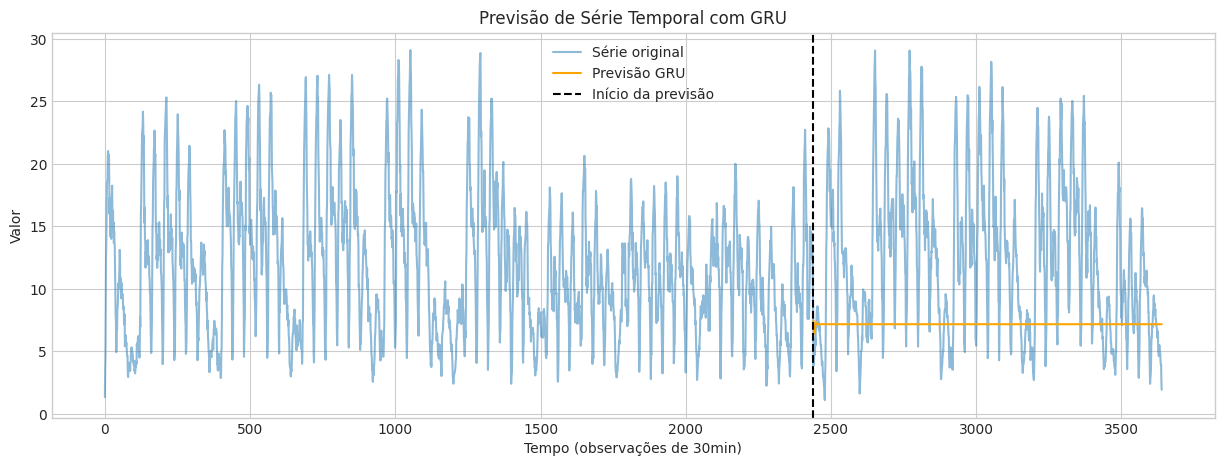

In [14]:
# --- 7. Plot
plt.figure(figsize=(15,5))
plt.plot(t, serie, label="Série original", alpha=0.5)
plt.plot(t[train_points:train_points+future_steps], predictions, label="Previsão GRU", color="orange")
plt.axvline(x=train_points, color='k', linestyle='--', label="Início da previsão")
plt.legend()
plt.title("Previsão de Série Temporal com GRU")
plt.xlabel("Tempo (observações de 30min)")
plt.ylabel("Valor")
plt.grid(True)
plt.show()